#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 1: Titanic  </center>

En esta actividad se trabajará con el dataset [Titanic](https://www.kaggle.com/c/titanic/overview) disponible en Kaggle. El objetivo es predecir si un pasajero sobrevivirá a partir de atributos personales. La descripción de los atributos se encuentra en la misma [página](https://www.kaggle.com/c/titanic/data) en que se pueden bajar los datos.

## Objetivos Generales del Taller
 - Abordar un problema de aprendizaje automático de punta a punta
 - Familiarizarse con la biblioteca **pandas** para levantar y explorar los datos
 - Familiarizarse con los **pipelines** de **scikit-learn** como una forma de resolver un problema en forma ordenada.

## Formas de trabajo

Se podrá elegir entre dos formas de trabajo: instalación local o Colab. Para trabajar en clase Colab es completamente adecuado. Para ejecutar corridas que demanden mucho tiempo (por ejemplo, búsqueda de hiperparámetros) puede ser conveniente trabajar localmente. A continuación se explica cómo proceder en cada caso. Cualquiera sea la elección se recomienda trabajar con `scikit-learn>1.1.0`.

### Opción 1: Trabajar localmente

####  Ambiente de Trabajo

Deberá trabajar en su propio ambiente de desarrollo. Ej: **conda environment**.  En caso de no contar con uno deberá crearlo ejecutando la siguiente línea de comando:

`conda create -n TAA-py310 python=3.11`  

Una vez creado se procede a activarlo:

`conda activate TAA-py311`  

Una vez activado se instalan en el entorno los paquetes que se utilizaran:

`pip install numpy matplotlib pandas "scikit-learn>1.1.0" notebook`   

Una vez finalizada la instalación abra el Jupyter Notebook:

`jupyter-notebook`

Los paquetes faltantes se pueden instalar desde el notebook haciendo:    

`!pip install paquete_faltante`

####  Configuración del API token

A continuación, vaya a su cuenta de [Kaggle](https://www.kaggle.com/) (o cree una si aún no lo ha hecho), haga clic en el icono de perfil en la esquina superior derecha de la pantalla y seleccione "Your Account" en la lista desplegable. Luego, seleccione la viñeta "Settings" y en la sección API, ir a la subsección "Legacy API Credentials". Allí, cliquear en  "Create a Legacy API Key". Entonces un archivo llamado kaggle.json se descargará automáticamente a su carpeta de descargas. Este archivo contiene sus credenciales de inicio de sesión para permitirle acceder a la API.



Cree (en caso de no existir) la carpeta `.kaggle`. Modifique *nombre_usuario* por el nombre del usuario donde está trabajando.

In [ ]:
!mkdir C:\Users\nombre_usuario\.kaggle

Mueva el archivo descargado a la carpeta creada.

In [ ]:
#Comando en Windows
!move C:\Users\nombre_usuario\Downloads\kaggle.json C:\Users\nombre_usuario\.kaggle


#Comando en Linux
# !mv C:\Users\nombre_usuario\Downloads\kaggle.json C:\Users\nombre_usuario\.kaggle

/bin/bash: line 1: move: command not found


### Opción 2:  Trabajar en *Colab*.

Se puede trabajar en Google Colab. Para ello es necesario contar con una cuenta de **google drive** y ejecutar un notebook almacenado en dicha cuenta. De lo contrario, no se conservarán los cambios realizados en la sesión. En caso de ya contar con una cuenta, se puede abrir el notebook y luego ir a `Archivo-->Guardar una copia en drive`.  

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/TAA-fing/TAA-2024/blob/main/talleres/taller1_titanic.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Ejecutar en Google Colab</a>
  </td>
</table>

La siguiente celda monta el disco personal del drive:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


####  Configuración del API token en Colab

A continuación, vaya a su cuenta de [Kaggle](https://www.kaggle.com/) (o cree una si aún no lo ha hecho), haga clic en el icono de perfil en la esquina superior derecha de la pantalla y seleccione "Your Account" en la lista desplegable. Luego, seleccione la viñeta "Settings" y en la sección API, ir a la subsección "Legacy API Credentials". Allí, cliquear en  "Create a Legacy API Key". Entonces un archivo llamado kaggle.json se descargará automáticamente a su carpeta de descargas. Este archivo contiene sus credenciales de inicio de sesión para permitirle acceder a la API.

La siguiente celda realiza la configuración necesaria para obtener datos desde la plataforma Kaggle. Le solicitará que suba el archivo kaggle.json descargado anteriormente.

In [ ]:
import warnings
warnings.filterwarnings('ignore')
from google.colab import files

# El siguiente archivo solicitado es para habilitar la API de Kaggle en el entorno que está trabajando.
# Este archivo se descarga entrando a su perfíl de Kaggle, en la sección Settings/API, presionando donde dice: Create New Token

uploaded = files.upload()

for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

#Then move kaggle.json into the folder where the API expects to find it.
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 70 bytes


## Descarga de los datos

###  Unirse a la competición

Vaya a la competición de [Titanic](https://www.kaggle.com/c/titanic) en Kaggle y presione **Join Competition**.

###  Instalar el paquete *kaggle*

Para obtener los datos de Kaggle primero se instalará la librería de **Kaggle**

In [ ]:
!pip install kaggle

Si la instalación fue exitosa, el siguiente comando debería mostrar una lista de todas las competiciones activas de Kaggle.

In [ ]:
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3    2026-04-15 23:59:00  Featured  2,207,152 Usd       3369           False  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection  

####  Descargar y descomprimir los datos

Ejecutar el siguiente comando para bajar los datos de la competencia *titanic*.

In [ ]:
!kaggle competitions download -c titanic

100% 34.1k/34.1k [00:00<00:00, 11.9MB/s]



Descomprima el archivo descargado:

In [ ]:
# Forma 1
!unzip titanic.zip

# Forma 2
# import zipfile
# with zipfile.ZipFile("titanic.zip","r") as zip_ref:
#     zip_ref.extractall("./")

Archive:  titanic.zip
  inflating: gender_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


##  Parte 1 - Carga de datos

In [ ]:
import pandas as pd

#### Ejercicios:

 - Levantar el conjunto de entrenamiento utilizando el método `read_csv()` de la biblioteca **pandas**.
 - Explorar los métodos `head()`, `info()` y `describe()` para obtener información relevante de los datos.

In [ ]:
# data_train
data_train = pd.read_csv('train.csv')

In [ ]:
# primeras n filas
data_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# resumen de datos y tipos
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# resumen estadistico
data_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Parte 2 - Exploración con pandas

#### Ejemplos de manipulación con Pandas  

**1)** Ejemplo de filtrado utilizando `df.loc[..]`. ¿Quiénes eran los pasajeros mayores de 60 años que viajaban en tercera clase? ¿Cuáles sobrevivieron?

In [ ]:
data_train.loc[(data_train['Age'] > 60) & (data_train['Pclass'] == 3)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
280,281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
326,327,0,3,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,NaN,S
483,484,1,3,"Turkula, Mrs. (Hedwig)",female,63.0,0,0,4134,9.5875,NaN,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [ ]:
data_train.loc[(data_train['Age'] > 60) & (data_train['Pclass'] == 3) & (data_train['Survived'] == 1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
483,484,1,3,"Turkula, Mrs. (Hedwig)",female,63.0,0,0,4134,9.5875,NaN,S


**2)**  Ejemplo de manipular columnas y filas de dataframes. Generar un vector con las etiquetas a partir del nombre.

In [ ]:
y_target = data_train['Survived']
y_target

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [ ]:
y_target = data_train.loc[:, 'Survived']
y_target

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


**3)** Generar el vector de etiquetas a partir del número de la columna.  

In [ ]:
column_names = data_train.columns.to_list()
print(column_names)

index_survived = column_names.index('Survived')
print(index_survived)

y_target = data_train.iloc[:,index_survived]
y_target

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
1


,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


#### Ejercicios:
 - Identificar el atributo a predecir
 - Obtener el porcentaje de pasajeros del conjunto de entrenamiento que sobrevivió. ¿Es un problema de clases desbalanceadas?
 - Identificar los atributos numéricos y categóricos.
 - En caso de contar con datos categóricos identifique las categorías.
 - Obtener el porcentaje de pasajeros dentro de cada categoría que sobrevivió. Asegúrese de poder responder preguntas del tipo: ¿Qué porcentaje de mujeres sobrevivieron? ¿Cuál fue el porcentaje de pasajeros de primera clase (PClass 1) que sobrevivió?)
 - Identificar y cuantificar datos faltantes.


In [ ]:
pred = data_train['Survived']
pred.value_counts(normalize=True)


,proportion
Survived,
0,0.616162
1,0.383838


In [ ]:
data_train.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
data_train['Sex'].value_counts(normalize=True) * 100

,proportion
Sex,
male,64.758698
female,35.241302


In [ ]:
data_train.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [ ]:
data_train.groupby(['Pclass'])['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [ ]:
data_train.groupby(['Embarked'])['Survived'].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


In [ ]:
faltantes = data_train.isnull().sum()
total = len(data_train)

df_faltantes = pd.DataFrame({
    'faltantes': faltantes,
    'total': total,
    'porcentaje': (faltantes / total) * 100
})

df_faltantes

,faltantes,total,porcentaje
PassengerId,0,891,0.000000
Survived,0,891,0.000000
Pclass,0,891,0.000000
Name,0,891,0.000000
Sex,0,891,0.000000
Age,177,891,19.865320
SibSp,0,891,0.000000
Parch,0,891,0.000000
Ticket,0,891,0.000000
Fare,0,891,0.000000


## Parte 3 - Descubrir y visualizar los datos para obtener información relevante.  


 - Explore [métodos de visualización](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.html) con **pandas**. Para graficar con *pandas* es necesario importar *matplotlib*. Puede ser útil comparar los histogramas de cada clase contra los histogramas de supervivencia en cada clase.
 - Estudie la correlación de las características con la etiqueta a predecir. Se sugiere utilizar el método `corr()`.
 - Concluya que factores tuvieron mayor incidencia en la supervivencia o no de un pasajero.

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

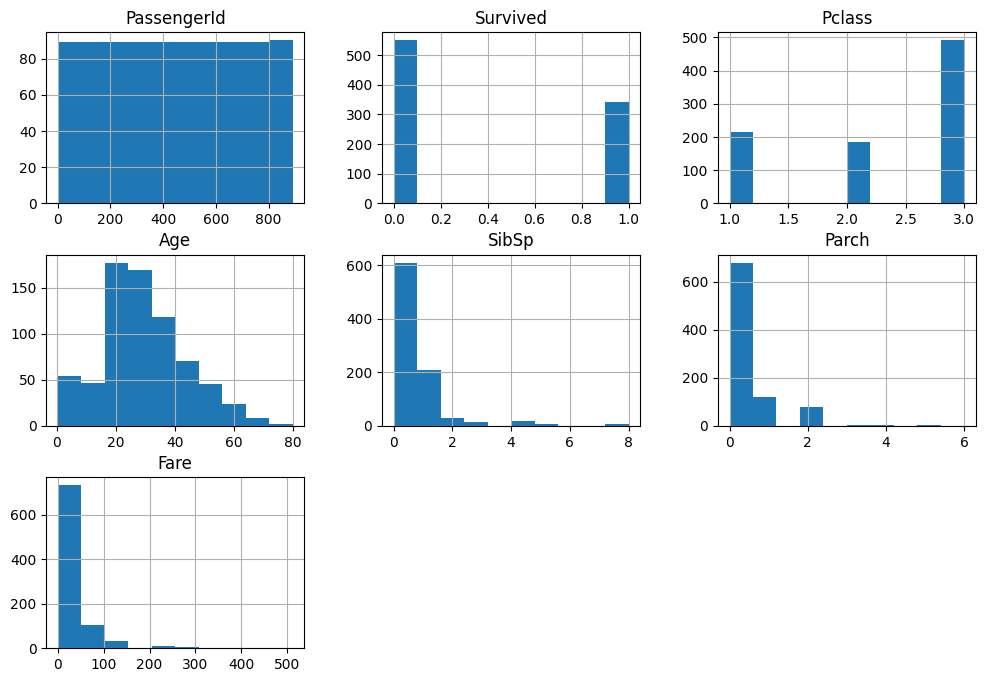

In [ ]:
data_train.hist(figsize=(12,8))

<Axes: xlabel='Sex'>

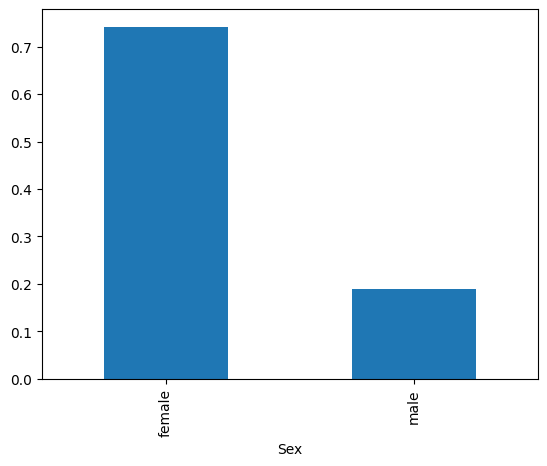

In [ ]:
data_train.groupby('Sex')['Survived'].mean().plot(kind='bar')


<Axes: xlabel='Pclass'>

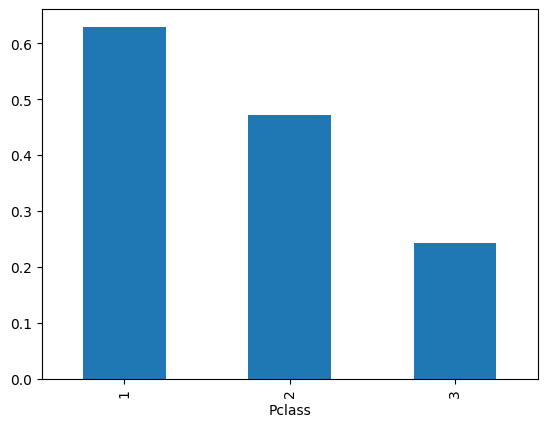

In [ ]:
data_train.groupby('Pclass')['Survived'].mean().plot(kind='bar')

<Axes: xlabel='Embarked'>

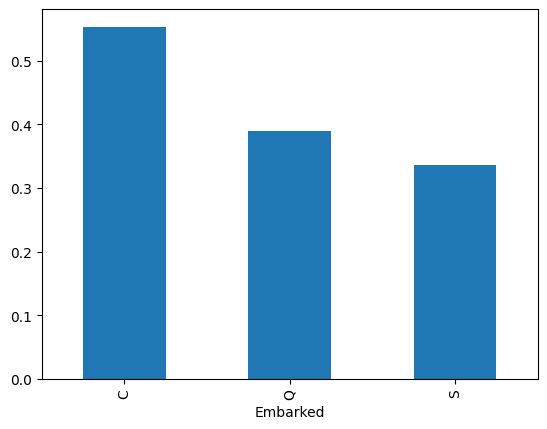

In [ ]:
data_train.groupby('Embarked')['Survived'].mean().plot(kind='bar')

<Axes: xlabel='Sex'>

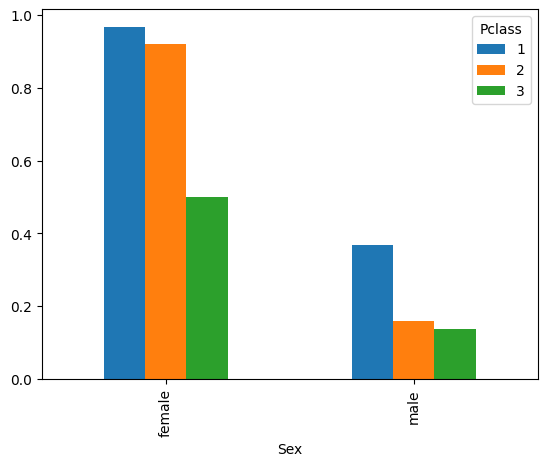

In [ ]:
data_train.groupby(['Sex','Pclass'])['Survived'].mean().unstack().plot(kind='bar')

In [ ]:
data_train.corr(numeric_only=True)['Survived'].sort_values(ascending=False)

,Survived
Survived,1.000000
Fare,0.257307
Parch,0.081629
PassengerId,-0.005007
SibSp,-0.035322
Age,-0.077221
Pclass,-0.338481


## Parte 4 - Un Primer Pipeline

- Construir un **pipeline** que realice el preprocesamiento de los datos necesario para que éstos puedan ser utilizados por un clasificador de *sklearn*. Dicho preprocesamiento deberá en primera instancia realizar las siguientes tareas:

    1. Descartar los atributos *Cabin*, *Name* y *Ticket*.
    2. Rellenar datos faltantes con algún criterio elegido

In [ ]:
X = data_train.drop(columns=['Survived', 'PassengerId', 'Cabin', 'Name', 'Ticket'])
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [ ]:
from sklearn.impute import SimpleImputer

num_cols = ['Age', 'Fare']
num_imputer = SimpleImputer(strategy='median')

X[num_cols] = num_imputer.fit_transform(X[num_cols])

In [ ]:
X = X.dropna(subset=['Embarked'])

In [ ]:
faltantes = X.isnull().sum()
total = len(X)

df_faltantes = pd.DataFrame({
    'faltantes': faltantes,
    'total': total,
    'porcentaje': (faltantes / total) * 100
})

df_faltantes

,faltantes,total,porcentaje
Pclass,0,889,0.0
Sex,0,889,0.0
Age,0,889,0.0
SibSp,0,889,0.0
Parch,0,889,0.0
Fare,0,889,0.0
Embarked,0,889,0.0


Llevarlo adentro de un PIPELINE:

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_cols = ['Age', 'Fare']
cat_cols = ['Pclass', 'Sex', 'Embarked']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [ ]:
data_tranformed = data_train.copy()
data_tranformed = preprocessor.fit_transform(data_tranformed)

data_transformed_df = pd.DataFrame(
    data_transformed,
    columns=preprocessor.get_feature_names_out()
)

data_transformed_df.head()

,num__Age,num__Fare,cat__Pclass_1,cat__Pclass_2,cat__Pclass_3,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S
0,22.0,7.2500,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,38.0,71.2833,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,26.0,7.9250,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,35.0,53.1000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,35.0,8.0500,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


- Acceda a los elementos del pipeline. Para acceder a las distintas transformaciones se usa `named_transformers_` y para acceder a los steps de cada transformación `named_steps`  

In [ ]:
preprocessor.get_feature_names_out()

array(['num__Age', 'num__Fare', 'cat__Pclass_1', 'cat__Pclass_2',
       'cat__Pclass_3', 'cat__Sex_female', 'cat__Sex_male',
       'cat__Embarked_C', 'cat__Embarked_Q', 'cat__Embarked_S'],
      dtype=object)

In [ ]:
preprocessor.named_transformers_

{'num': Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]),
 'cat': Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                 ('ohe', OneHotEncoder(handle_unknown='ignore'))]),
 'remainder': 'drop'}

In [ ]:
preprocessor.named_transformers_['cat'].named_steps['ohe'].categories_

[array([1, 2, 3], dtype=object),
 array(['female', 'male'], dtype=object),
 array(['C', 'Q', 'S'], dtype=object)]

## Parte 5 - Un Segundo Pipeline

- Realizar un **pipeline** que utilice como único atributo el género del pasajero.

In [ ]:
Sex_column = data_train.copy()

preprocessor_Sex = ColumnTransformer([
    ('sex', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), ['Sex'])
])

Sex_column = data_train.copy()
Sex_column = preprocessor_Sex.fit_transform(Sex_column)
Sex_column_df = pd.DataFrame(
    Sex_column,
    columns=preprocessor_Sex.get_feature_names_out()
)

Sex_column_df.head()

,sex__Sex_female,sex__Sex_male
0,0.0,1.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,0.0,1.0


## Parte 6 - Clasificación con Regresión Logística

- Con los datos procesados por los pipelines de la Parte 4 y Parte 5 entrenar un modelo de *Regresión Logística* con parámetros por defecto y estimar el desempeño mediante validación cruzada 5-folds.
- Observe los desempeños obtenidos. ¿Qué puede decir sobre los datos? ¿Y sobre el modelo?

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
data_x = data_train.copy()
data_y = data_train['Survived']

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

scores = cross_val_score(pipeline, data_x, data_y, cv=5, scoring='accuracy')

print("Scores por fold:", scores)
print("Accuracy promedio:", scores.mean())
print("Desvío estándar:", scores.std())

Scores por fold: [0.80446927 0.80337079 0.78651685 0.75280899 0.78651685]
Accuracy promedio: 0.7867365513778168
Desvío estándar: 0.018667207932566335


## Parte 7 - Busqueda de Hiperparámetros

- Utilizar *Grid Search* para encontrar el valor óptimo del parámetro *C* del mejor clasificador de *Regresión Logística* obtenido de la parte anterior.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_cols = ['Age', 'Fare']
cat_cols = ['Pclass', 'Sex', 'Embarked']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

Preprocessor

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

data_x = data_train.copy()
data_y = data_train['Survived']

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(data_x, data_y)

print("Mejor parámetro C:", grid_search.best_params_)
print("Mejor accuracy promedio:", grid_search.best_score_)
print("Mejor modelo:", grid_search.best_estimator_)

Mejor parámetro C: {'model__C': 0.1}
Mejor accuracy promedio: 0.7901324461741259
Mejor modelo: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex',
                                                   'Embarked'])])),
 

## Parte 8 - Guardar Modelo

- Guarde el modelo obtenido de la parte anterior.

*Observación: Es usual que entrenar modelos tome un tiempo considerable por lo que el guardado del modelo resulta de vital importancia.*

In [ ]:
import joblib

best_model = grid_search.best_estimator_

joblib.dump(best_model, 'logistic_regression_titanic.pkl')

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


In [ ]:
loaded_model = joblib.load('logistic_regression_titanic.pkl')
print(loaded_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex',
                                                   'Embarked'])])),
                ('model', LogisticRegression(C=0.1))])


## Parte 9 - Generar predicciones en conjunto de test

- Levante el modelo guardado en la parte anterior.
- Genere las predicciones con el conjunto de test.

In [ ]:
data_test = pd.read_csv("test.csv")
print(data_test.head())
print(data_test.columns)

   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   

    Age  SibSp  Parch   Ticket     Fare Cabin Embarked  
0  34.5      0      0   330911   7.8292   NaN        Q  
1  47.0      1      0   363272   7.0000   NaN        S  
2  62.0      0      0   240276   9.6875   NaN        Q  
3  27.0      0      0   315154   8.6625   NaN        S  
4  22.0      1      1  3101298  12.2875   NaN        S  
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [ ]:
import joblib

# Levantar el modelo guardado
loaded_model = joblib.load('logistic_regression_titanic.pkl')

# Generar predicciones sobre el conjunto de test
test_predictions = loaded_model.predict(data_test)

print("Cantidad de predicciones:", len(test_predictions))
print("Primeras predicciones:", test_predictions[:10])

Cantidad de predicciones: 418
Primeras predicciones: [0 0 0 0 1 0 1 0 1 0]


In [ ]:
import numpy as np

unique, counts = np.unique(test_predictions, return_counts=True)

for val, count in zip(unique, counts):
    print(f"Clase {val}: {count} casos")

Clase 0: 265 casos
Clase 1: 153 casos


## Parte 10 - Generar una Kaggle Submission

- Generar una Kaggle Submission utilizando las prediciones obtenidas en el conjunto de Test. Puede ver un ejemplo de como hacerlo [aquí](https://www.kaggle.com/jlawman/complete-beginner-your-first-titanic-submission?scriptVersionId=1700267&cellId=17).

In [ ]:
import pandas as pd

submission = pd.DataFrame({
    'PassengerId': data_test['PassengerId'],
    'Survived': test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [ ]:
submission.to_csv('my_first_titanic_predictions.csv', index=False)

print("Archivo generado correctamente.")
import os
print(os.listdir())

Archivo generado correctamente.
['.config', 'logistic_regression_titanic.pkl', 'gender_submission.csv', 'drive', 'titanic.zip', 'my_first_titanic_predictions.csv', 'C:Usersnombre_usuario.kaggle', 'test.csv', 'train.csv', 'sample_data']


Una vez generado el archivo *.csv*, la submission se puede realizar subiendo directamente el archivo a la página de Kaggle o desde la línea de comandos como:

`!kaggle competitions submit -c [COMPETITION] -f [FILE] -m [MESSAGE]`  

In [ ]:
!kaggle competitions submit -c titanic -f my_first_titanic_predictions.csv -m primer_submission

100% 2.77k/2.77k [00:00<00:00, 4.18kB/s]
Successfully submitted to Titanic - Machine Learning from Disaster

## Parte 11 - En busca de un mejor modelo

- Generar un nuevo **pipeline** y evaluar si éste genera un mejor clasificador. Algunas de las opciones que se pueden explorar son las siguientes:
    * Evaluar la característica Pclass como dato numérico, ordinal o categórico.    
    * Estudiar qué escalado sirve en los atributos numéricos   
    * Agregar nuevas características y/o sustituir las existentes. Por ejemplo:   
        - Reemplazar *SibSp* y *Parch* por la suma     
        - Discretizar algún atributo numérico, por ejemplo la edad.
    * Estudiar algún modelo alternativo (*Se sugiere experimentar con SVM o RandomForestClassifier*)
    * Construir un **pipeline** que permita determinar automáticamente qué grupo de características utilizar y qué estrategia seguir para lidiar con datos faltantes.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OrdinalEncoder,
    KBinsDiscretizer,
    FunctionTransformer
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectPercentile, f_classif

X = data_train.drop(columns=['Survived'])
y = data_train['Survived']

def evaluar_modelo(nombre, pipeline, X, y, cv=5):
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
    print(f"{nombre}")
    print(f"Scores: {scores}")
    print(f"Accuracy promedio: {scores.mean():.4f}")
    print(f"Desvío estándar: {scores.std():.4f}")
    print("-" * 60)

In [ ]:
# Variables base
num_base = ['Age', 'Fare']
cat_base = ['Sex', 'Embarked']

# 1) Pclass como numérico
preprocessor_pclass_num = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), ['Age', 'Fare', 'Pclass']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_base)
])

pipeline_pclass_num = Pipeline([
    ('preprocessor', preprocessor_pclass_num),
    ('model', LogisticRegression(max_iter=1000))
])

# 2) Pclass como ordinal
preprocessor_pclass_ord = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_base),
    ('ord', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ordenc', OrdinalEncoder(categories=[[1, 2, 3]]))
    ]), ['Pclass']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_base)
])

pipeline_pclass_ord = Pipeline([
    ('preprocessor', preprocessor_pclass_ord),
    ('model', LogisticRegression(max_iter=1000))
])

# 3) Pclass como categórico
preprocessor_pclass_cat = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_base),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), ['Pclass', 'Sex', 'Embarked'])
])

pipeline_pclass_cat = Pipeline([
    ('preprocessor', preprocessor_pclass_cat),
    ('model', LogisticRegression(max_iter=1000))
])

evaluar_modelo("Pclass numérico", pipeline_pclass_num, X, y)
evaluar_modelo("Pclass ordinal", pipeline_pclass_ord, X, y)
evaluar_modelo("Pclass categórico", pipeline_pclass_cat, X, y)

Pclass numérico
Scores: [0.77653631 0.78651685 0.7752809  0.76966292 0.79213483]
Accuracy promedio: 0.7800
Desvío estándar: 0.0081
------------------------------------------------------------
Pclass ordinal
Scores: [0.77653631 0.78651685 0.7752809  0.76966292 0.79213483]
Accuracy promedio: 0.7800
Desvío estándar: 0.0081
------------------------------------------------------------
Pclass categórico
Scores: [0.78212291 0.80898876 0.78089888 0.76966292 0.80337079]
Accuracy promedio: 0.7890
Desvío estándar: 0.0148
------------------------------------------------------------


In [ ]:
# Fijamos Pclass como categórico y comparamos escalados en Age/Fare
scalers = {
    'sin_escalado': 'passthrough',
    'standard': StandardScaler(),
    'minmax': MinMaxScaler(),
    'robust': RobustScaler()
}

for nombre_scaler, scaler in scalers.items():
    preprocessor_scaling = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', scaler)
        ]), ['Age', 'Fare']),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), ['Pclass', 'Sex', 'Embarked'])
    ])

    pipeline_scaling = Pipeline([
        ('preprocessor', preprocessor_scaling),
        ('model', LogisticRegression(max_iter=1000))
    ])

    evaluar_modelo(f"Escalado: {nombre_scaler}", pipeline_scaling, X, y)

Escalado: sin_escalado
Scores: [0.78212291 0.81460674 0.78089888 0.76966292 0.80337079]
Accuracy promedio: 0.7901
Desvío estándar: 0.0164
------------------------------------------------------------
Escalado: standard
Scores: [0.78212291 0.80898876 0.78089888 0.76966292 0.80337079]
Accuracy promedio: 0.7890
Desvío estándar: 0.0148
------------------------------------------------------------
Escalado: minmax
Scores: [0.78212291 0.80337079 0.78089888 0.7752809  0.79213483]
Accuracy promedio: 0.7868
Desvío estándar: 0.0099
------------------------------------------------------------
Escalado: robust
Scores: [0.78212291 0.80898876 0.78089888 0.76966292 0.80337079]
Accuracy promedio: 0.7890
Desvío estándar: 0.0148
------------------------------------------------------------


In [ ]:
def crear_family_size(df):
    df = df.copy()
    return pd.DataFrame({
        'FamilySize': df['SibSp'].fillna(0) + df['Parch'].fillna(0)
    }, index=df.index)

# Baseline con SibSp y Parch por separado
preprocessor_baseline_family = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), ['Age', 'Fare', 'SibSp', 'Parch']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), ['Pclass', 'Sex', 'Embarked'])
])

pipeline_baseline_family = Pipeline([
    ('preprocessor', preprocessor_baseline_family),
    ('model', LogisticRegression(max_iter=1000))
])

# Variante con FamilySize
preprocessor_family_size = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), ['Age', 'Fare']),
    ('family', Pipeline([
        ('make_family', FunctionTransformer(crear_family_size, validate=False)),
        ('scaler', StandardScaler())
    ]), ['SibSp', 'Parch']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), ['Pclass', 'Sex', 'Embarked'])
])

pipeline_family_size = Pipeline([
    ('preprocessor', preprocessor_family_size),
    ('model', LogisticRegression(max_iter=1000))
])

evaluar_modelo("Baseline con SibSp y Parch", pipeline_baseline_family, X, y)
evaluar_modelo("Con FamilySize = SibSp + Parch", pipeline_family_size, X, y)

Baseline con SibSp y Parch
Scores: [0.77653631 0.78651685 0.78651685 0.76966292 0.83146067]
Accuracy promedio: 0.7901
Desvío estándar: 0.0216
------------------------------------------------------------
Con FamilySize = SibSp + Parch
Scores: [0.77094972 0.80898876 0.78651685 0.78089888 0.83146067]
Accuracy promedio: 0.7958
Desvío estándar: 0.0218
------------------------------------------------------------


In [ ]:
# Baseline con Age continua
preprocessor_age_continua = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), ['Age', 'Fare']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), ['Pclass', 'Sex', 'Embarked'])
])

pipeline_age_continua = Pipeline([
    ('preprocessor', preprocessor_age_continua),
    ('model', LogisticRegression(max_iter=1000))
])

# Age discretizada
preprocessor_age_binned = ColumnTransformer([
    ('age_binned', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('kbins', KBinsDiscretizer(n_bins=5, encode='onehot-dense', strategy='quantile'))
    ]), ['Age']),
    ('fare', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), ['Fare']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), ['Pclass', 'Sex', 'Embarked'])
])

pipeline_age_binned = Pipeline([
    ('preprocessor', preprocessor_age_binned),
    ('model', LogisticRegression(max_iter=1000))
])

evaluar_modelo("Edad continua", pipeline_age_continua, X, y)
evaluar_modelo("Edad discretizada", pipeline_age_binned, X, y)

Edad continua
Scores: [0.78212291 0.80898876 0.78089888 0.76966292 0.80337079]
Accuracy promedio: 0.7890
Desvío estándar: 0.0148
------------------------------------------------------------
Edad discretizada
Scores: [0.7877095  0.80898876 0.78089888 0.78089888 0.79213483]
Accuracy promedio: 0.7901
Desvío estándar: 0.0104
------------------------------------------------------------


In [ ]:
# Preprocesamiento para SVM / Logistic
preprocessor_svm = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), ['Age', 'Fare', 'SibSp', 'Parch']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), ['Pclass', 'Sex', 'Embarked'])
])

pipeline_logreg = Pipeline([
    ('preprocessor', preprocessor_svm),
    ('model', LogisticRegression(max_iter=1000, C=0.1))
])

pipeline_svm = Pipeline([
    ('preprocessor', preprocessor_svm),
    ('model', SVC(kernel='rbf', C=1.0))
])

# Preprocesamiento para RandomForest
preprocessor_rf = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ]), ['Age', 'Fare', 'SibSp', 'Parch']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), ['Pclass', 'Sex', 'Embarked'])
])

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        random_state=42
    ))
])

evaluar_modelo("Logistic Regression", pipeline_logreg, X, y)
evaluar_modelo("SVM", pipeline_svm, X, y)
evaluar_modelo("Random Forest", pipeline_rf, X, y)

Logistic Regression
Scores: [0.78212291 0.80898876 0.79213483 0.76404494 0.83146067]
Accuracy promedio: 0.7958
Desvío estándar: 0.0230
------------------------------------------------------------
SVM
Scores: [0.82681564 0.82022472 0.81460674 0.81460674 0.85955056]
Accuracy promedio: 0.8272
Desvío estándar: 0.0168
------------------------------------------------------------
Random Forest
Scores: [0.80446927 0.80898876 0.85393258 0.79775281 0.85393258]
Accuracy promedio: 0.8238
Desvío estándar: 0.0248
------------------------------------------------------------


In [ ]:
def crear_family_size(df):
    df = df.copy()
    return pd.DataFrame({
        'FamilySize': df['SibSp'].fillna(0) + df['Parch'].fillna(0)
    }, index=df.index)

# Preprocesador A: básico
preprocessor_a = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), ['Age', 'Fare']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent', fill_value='missing')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), ['Pclass', 'Sex', 'Embarked'])
])

# Preprocesador B: agrega SibSp y Parch
preprocessor_b = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), ['Age', 'Fare', 'SibSp', 'Parch']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent', fill_value='missing')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), ['Pclass', 'Sex', 'Embarked'])
])

# Preprocesador C: usa FamilySize en vez de SibSp y Parch
preprocessor_c = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), ['Age', 'Fare']),
    ('family', Pipeline([
        ('make_family', FunctionTransformer(crear_family_size, validate=False)),
        ('scaler', StandardScaler())
    ]), ['SibSp', 'Parch']),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent', fill_value='missing')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), ['Pclass', 'Sex', 'Embarked'])
])

pipe_auto = Pipeline([
    ('preprocessor', preprocessor_a),
    ('selector', SelectPercentile(score_func=f_classif)),
    ('model', LogisticRegression(max_iter=1000))
])

param_grid = {
    'preprocessor': [preprocessor_a, preprocessor_b, preprocessor_c],
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant'],
    'selector__percentile': [60, 80, 100],
    'model__C': [0.01, 0.1, 1, 10]
}

grid_auto = GridSearchCV(
    pipe_auto,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_auto.fit(X, y)

print("Mejores parámetros:")
print(grid_auto.best_params_)
print()
print(f"Mejor accuracy promedio: {grid_auto.best_score_:.4f}")
print()
print("Mejor pipeline:")
print(grid_auto.best_estimator_)

Mejores parámetros:
{'model__C': 0.1, 'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Fare']),
                                ('family',
                                 Pipeline(steps=[('make_family',
                                                  FunctionTransformer(func=<function crear_family_size at 0x7beb1b533b00>)),
                                                 ('scaler', StandardScaler())]),
                                 ['SibSp', 'Parch']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy=

In [ ]:
candidatos = {
    'Pclass categórico + LR': pipeline_pclass_cat,
    'FamilySize + LR': pipeline_family_size,
    'Edad discretizada + LR': pipeline_age_binned,
    'SVM': pipeline_svm,
    'Random Forest': pipeline_rf
}

for nombre, pipe in candidatos.items():
    evaluar_modelo(nombre, pipe, X, y)

Pclass categórico + LR
Scores: [0.78212291 0.80898876 0.78089888 0.76966292 0.80337079]
Accuracy promedio: 0.7890
Desvío estándar: 0.0148
------------------------------------------------------------
FamilySize + LR
Scores: [0.77094972 0.80898876 0.78651685 0.78089888 0.83146067]
Accuracy promedio: 0.7958
Desvío estándar: 0.0218
------------------------------------------------------------
Edad discretizada + LR
Scores: [0.7877095  0.80898876 0.78089888 0.78089888 0.79213483]
Accuracy promedio: 0.7901
Desvío estándar: 0.0104
------------------------------------------------------------
SVM
Scores: [0.82681564 0.82022472 0.81460674 0.81460674 0.85955056]
Accuracy promedio: 0.8272
Desvío estándar: 0.0168
------------------------------------------------------------
Random Forest
Scores: [0.80446927 0.80898876 0.85393258 0.79775281 0.85393258]
Accuracy promedio: 0.8238
Desvío estándar: 0.0248
------------------------------------------------------------
